# EBT Film Comparison: AIC-144 vs CCB

This notebook compares dose distributions from EBT film scans acquired at AIC-144 and CCB facilities.

In [15]:
# Imports
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Add src to path
project_root = Path.cwd().parents[2]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

# Import visualization utilities
from visualise.dose import create_dose_colormap

## Configuration

In [16]:
# Data directory (same as notebook location)
DATA_DIR = Path.cwd()

# File paths
AIC144_FILE = DATA_DIR / 'ebt_2D_aic144.npz'
CCB_FILE = DATA_DIR / 'ebt_2D_ccb.npz'

# Colormap parameters
CMAP_WHITE_THRESHOLD_PERCENT = 1.0

print(f'AIC-144 file exists: {AIC144_FILE.exists()}')
print(f'CCB file exists: {CCB_FILE.exists()}')

AIC-144 file exists: True
CCB file exists: True


## Load Data

In [17]:
# Load dose maps from npz files
aic144_data = np.load(AIC144_FILE)
ccb_data = np.load(CCB_FILE)

# Extract arrays (saved as first unnamed array -> 'arr_0')
dose_aic144 = aic144_data['arr_0']
dose_ccb = ccb_data['arr_0']

print(f'AIC-144 dose shape: {dose_aic144.shape}')
print(f'AIC-144 dose range: [{dose_aic144.min():.2f}, {dose_aic144.max():.2f}] Gy')
print()
print(f'CCB dose shape: {dose_ccb.shape}')
print(f'CCB dose range: [{dose_ccb.min():.2f}, {dose_ccb.max():.2f}] Gy')

AIC-144 dose shape: (264, 208)
AIC-144 dose range: [-0.00, 20.19] Gy

CCB dose shape: (262, 228)
CCB dose range: [0.02, 63.97] Gy


## Side-by-Side Dose Comparison

AIC-144 vmax (99th percentile): 17.62 Gy
CCB vmax (99th percentile): 14.56 Gy
Common vmax for comparison: 17.62 Gy
Strip width: 5.0 mm


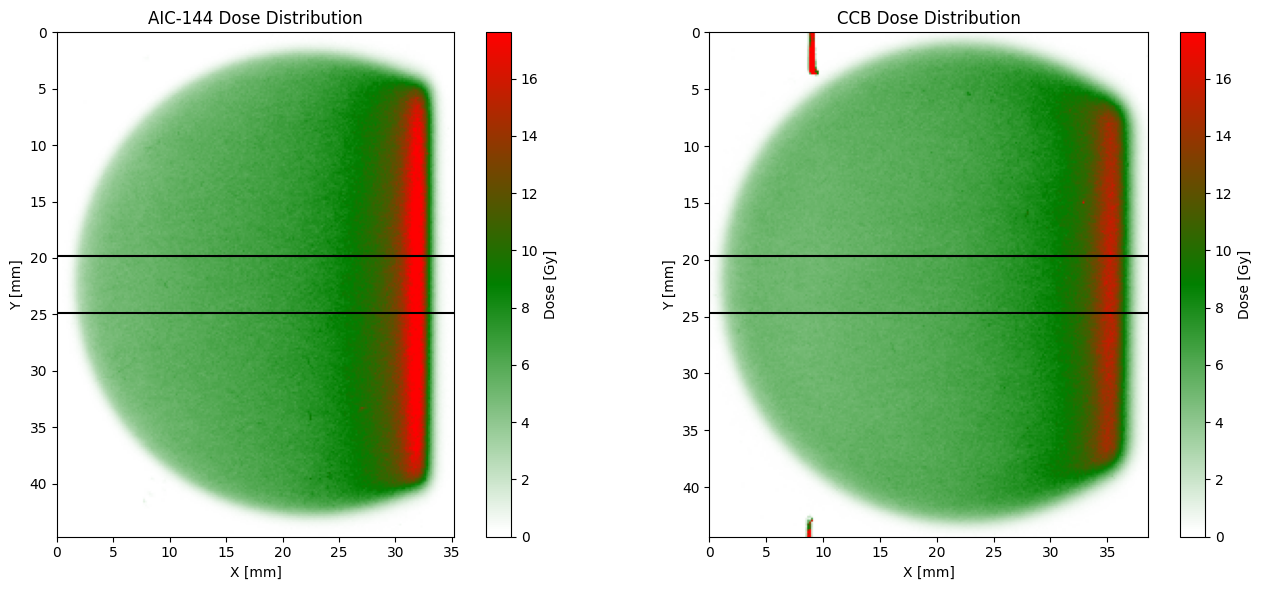

In [18]:
# Create dose colormap
cmap = create_dose_colormap(CMAP_WHITE_THRESHOLD_PERCENT)

# Pixel to mm conversion (150 dpi)
DPI = 150
px_to_mm = 25.4 / DPI

# Strip width for profile averaging
STRIP_WIDTH_MM = 5.0

# Calculate extents in mm
height_aic144, width_aic144 = dose_aic144.shape
extent_aic144 = [0, width_aic144 * px_to_mm, height_aic144 * px_to_mm, 0]
height_aic144_mm = height_aic144 * px_to_mm

height_ccb, width_ccb = dose_ccb.shape
extent_ccb = [0, width_ccb * px_to_mm, height_ccb * px_to_mm, 0]
height_ccb_mm = height_ccb * px_to_mm

# Calculate strip boundaries (centered on image)
strip_bottom_aic144 = height_aic144_mm / 2 + STRIP_WIDTH_MM / 2
strip_top_aic144 = height_aic144_mm / 2 - STRIP_WIDTH_MM / 2

strip_bottom_ccb = height_ccb_mm / 2 + STRIP_WIDTH_MM / 2
strip_top_ccb = height_ccb_mm / 2 - STRIP_WIDTH_MM / 2

# Calculate common vmax for comparison (using 99th percentile of positive values)
vmax_aic144 = np.percentile(dose_aic144[dose_aic144 > 0], 99) if (dose_aic144 > 0).any() else dose_aic144.max()
vmax_ccb = np.percentile(dose_ccb[dose_ccb > 0], 99) if (dose_ccb > 0).any() else dose_ccb.max()
vmax_common = max(vmax_aic144, vmax_ccb)

print(f'AIC-144 vmax (99th percentile): {vmax_aic144:.2f} Gy')
print(f'CCB vmax (99th percentile): {vmax_ccb:.2f} Gy')
print(f'Common vmax for comparison: {vmax_common:.2f} Gy')
print(f'Strip width: {STRIP_WIDTH_MM:.1f} mm')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# AIC-144 dose map (left)
im1 = ax1.imshow(dose_aic144, cmap=cmap, vmin=0, vmax=vmax_common, extent=extent_aic144, aspect='equal')
ax1.axhline(y=strip_top_aic144, color='black', linestyle='-', linewidth=1.5)
ax1.axhline(y=strip_bottom_aic144, color='black', linestyle='-', linewidth=1.5)
ax1.set_xlabel('X [mm]')
ax1.set_ylabel('Y [mm]')
ax1.set_title('AIC-144 Dose Distribution')
plt.colorbar(im1, ax=ax1, label='Dose [Gy]', fraction=0.046)

# CCB dose map (right)
im2 = ax2.imshow(dose_ccb, cmap=cmap, vmin=0, vmax=vmax_common, extent=extent_ccb, aspect='equal')
ax2.axhline(y=strip_top_ccb, color='black', linestyle='-', linewidth=1.5)
ax2.axhline(y=strip_bottom_ccb, color='black', linestyle='-', linewidth=1.5)
ax2.set_xlabel('X [mm]')
ax2.set_ylabel('Y [mm]')
ax2.set_title('CCB Dose Distribution')
plt.colorbar(im2, ax=ax2, label='Dose [Gy]', fraction=0.046)

plt.tight_layout()
plt.show()

## Horizontal Profiles Comparison

AIC-144 strip: rows 118 to 146 (28 rows)
CCB strip: rows 117 to 145 (28 rows)


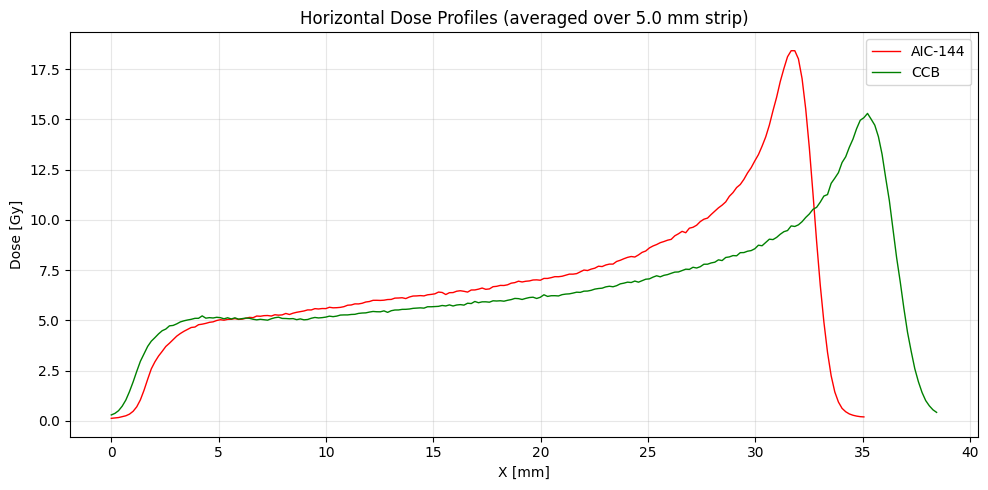

In [19]:
# Calculate strip indices in pixels for each image
strip_half_width_px = int((STRIP_WIDTH_MM / 2) / px_to_mm)

# AIC-144: center row and strip boundaries
center_row_aic144 = height_aic144 // 2
row_start_aic144 = center_row_aic144 - strip_half_width_px
row_end_aic144 = center_row_aic144 + strip_half_width_px

# CCB: center row and strip boundaries
center_row_ccb = height_ccb // 2
row_start_ccb = center_row_ccb - strip_half_width_px
row_end_ccb = center_row_ccb + strip_half_width_px

# Extract strips and average along Y (vertical) direction
profile_aic144 = dose_aic144[row_start_aic144:row_end_aic144, :].mean(axis=0)
profile_ccb = dose_ccb[row_start_ccb:row_end_ccb, :].mean(axis=0)

# Create X axis in mm
x_mm_aic144 = np.arange(len(profile_aic144)) * px_to_mm
x_mm_ccb = np.arange(len(profile_ccb)) * px_to_mm

print(f'AIC-144 strip: rows {row_start_aic144} to {row_end_aic144} ({row_end_aic144 - row_start_aic144} rows)')
print(f'CCB strip: rows {row_start_ccb} to {row_end_ccb} ({row_end_ccb - row_start_ccb} rows)')

# Plot profiles
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_mm_aic144, profile_aic144, color='red', label='AIC-144', linewidth=1)
ax.plot(x_mm_ccb, profile_ccb, color='green', label='CCB', linewidth=1)

ax.set_xlabel('X [mm]')
ax.set_ylabel('Dose [Gy]')
ax.set_title(f'Horizontal Dose Profiles (averaged over {STRIP_WIDTH_MM:.1f} mm strip)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Aligned Profiles (Max at Same Position)

AIC-144 max position: 31.67 mm (value: 18.42 Gy)
CCB max position: 35.22 mm (value: 15.30 Gy)


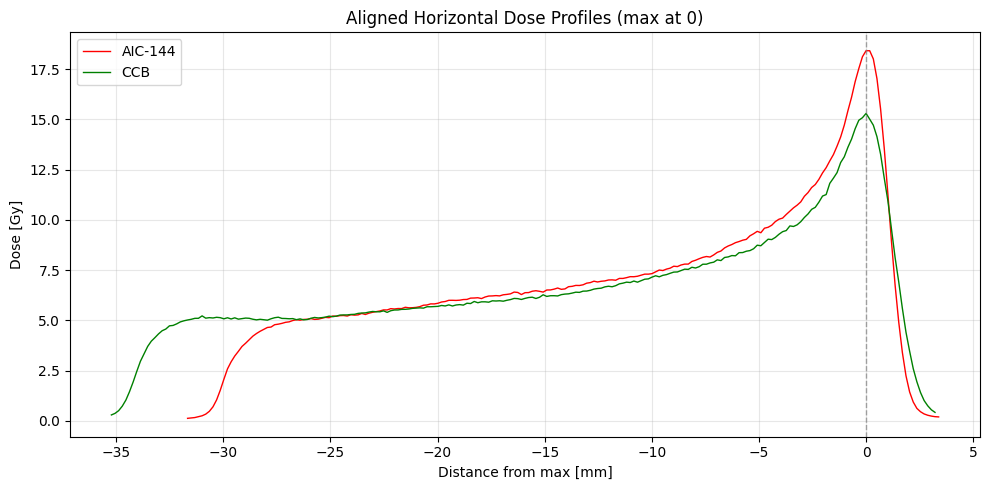

In [ ]:
# Find max positions
max_idx_aic144 = np.argmax(profile_aic144)
max_idx_ccb = np.argmax(profile_ccb)

max_pos_aic144_mm = x_mm_aic144[max_idx_aic144]
max_pos_ccb_mm = x_mm_ccb[max_idx_ccb]

print(f'AIC-144 max position: {max_pos_aic144_mm:.2f} mm (value: {profile_aic144[max_idx_aic144]:.2f} Gy)')
print(f'CCB max position: {max_pos_ccb_mm:.2f} mm (value: {profile_ccb[max_idx_ccb]:.2f} Gy)')

# Create aligned X axes (shift so max is at 0)
x_mm_aic144_aligned = x_mm_aic144 - max_pos_aic144_mm
x_mm_ccb_aligned = x_mm_ccb - max_pos_ccb_mm

# Helper function to find FWHM boundaries
def find_fwhm_boundaries(profile, x_mm):
    """Find left and right FWHM boundaries."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    half_max = max_val / 2
    
    left_pos = None
    right_pos = None
    
    # Left side
    for i in range(max_idx - 1, -1, -1):
        if profile[i] < half_max <= profile[i + 1]:
            frac = (half_max - profile[i]) / (profile[i + 1] - profile[i])
            left_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    # Right side
    for i in range(max_idx, len(profile) - 1):
        if profile[i] >= half_max > profile[i + 1]:
            frac = (half_max - profile[i]) / (profile[i + 1] - profile[i])
            right_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    return left_pos, right_pos, half_max

# Get FWHM boundaries for both profiles (in aligned coordinates)
left_aic144, right_aic144, hm_aic144 = find_fwhm_boundaries(profile_aic144, x_mm_aic144_aligned)
left_ccb, right_ccb, hm_ccb = find_fwhm_boundaries(profile_ccb, x_mm_ccb_aligned)

fwhm_aic144 = right_aic144 - left_aic144
fwhm_ccb = right_ccb - left_ccb

print(f'AIC-144 FWHM: {fwhm_aic144:.2f} mm')
print(f'CCB FWHM: {fwhm_ccb:.2f} mm')

# Plot aligned profiles
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_mm_aic144_aligned, profile_aic144, color='red', label='AIC-144', linewidth=1)
ax.plot(x_mm_ccb_aligned, profile_ccb, color='green', label='CCB', linewidth=1)

# Add FWHM horizontal segments
# AIC-144 FWHM segment (red)
ax.hlines(y=hm_aic144, xmin=left_aic144, xmax=right_aic144, color='red', linewidth=2, linestyle='-')
ax.text((left_aic144 + right_aic144) / 2, hm_aic144 + 0.3, f'{fwhm_aic144:.2f} mm', 
        ha='center', va='bottom', color='red', fontsize=10, fontweight='bold')

# CCB FWHM segment (green)
ax.hlines(y=hm_ccb, xmin=left_ccb, xmax=right_ccb, color='green', linewidth=2, linestyle='-')
ax.text((left_ccb + right_ccb) / 2, hm_ccb - 0.3, f'{fwhm_ccb:.2f} mm', 
        ha='center', va='top', color='green', fontsize=10, fontweight='bold')

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Distance from max [mm]')
ax.set_ylabel('Dose [Gy]')
ax.set_title(f'Aligned Horizontal Dose Profiles (max at 0)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Profile Metrics

In [22]:
def calculate_profile_metrics(profile, x_mm):
    """Calculate FWHM and distal falloff distances for a profile."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    
    # Normalize profile for percentage calculations
    profile_norm = profile / max_val * 100
    
    # FWHM: find positions where profile crosses 50%
    half_max = 50.0
    
    # Find left and right crossings
    left_idx = None
    right_idx = None
    
    # Left side (before max)
    for i in range(max_idx - 1, -1, -1):
        if profile_norm[i] < half_max <= profile_norm[i + 1]:
            # Linear interpolation
            frac = (half_max - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
            left_idx = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    # Right side (after max) - distal
    for i in range(max_idx, len(profile_norm) - 1):
        if profile_norm[i] >= half_max > profile_norm[i + 1]:
            frac = (half_max - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
            right_idx = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    fwhm = right_idx - left_idx if (left_idx is not None and right_idx is not None) else np.nan
    
    # Distal falloff: find positions for different percentages
    def find_distal_position(target_percent):
        for i in range(max_idx, len(profile_norm) - 1):
            if profile_norm[i] >= target_percent > profile_norm[i + 1]:
                frac = (target_percent - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
                return x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
        return np.nan
    
    pos_90 = find_distal_position(90.0)
    pos_80 = find_distal_position(80.0)
    pos_20 = find_distal_position(20.0)
    pos_10 = find_distal_position(10.0)
    
    dist_90_10 = pos_10 - pos_90 if not (np.isnan(pos_90) or np.isnan(pos_10)) else np.nan
    dist_80_20 = pos_20 - pos_80 if not (np.isnan(pos_80) or np.isnan(pos_20)) else np.nan
    
    return {
        'fwhm': fwhm,
        'dist_90_10': dist_90_10,
        'dist_80_20': dist_80_20
    }

# Calculate metrics for both profiles
metrics_aic144 = calculate_profile_metrics(profile_aic144, x_mm_aic144)
metrics_ccb = calculate_profile_metrics(profile_ccb, x_mm_ccb)

# Display table
print(f'{"Dataset":<12} {"FWHM [mm]":>12} {"90%-10% [mm]":>14} {"80%-20% [mm]":>14}')
print('-' * 54)
print(f'{"AIC-144":<12} {metrics_aic144["fwhm"]:>12.2f} {metrics_aic144["dist_90_10"]:>14.2f} {metrics_aic144["dist_80_20"]:>14.2f}')
print(f'{"CCB":<12} {metrics_ccb["fwhm"]:>12.2f} {metrics_ccb["dist_90_10"]:>14.2f} {metrics_ccb["dist_80_20"]:>14.2f}')

Dataset         FWHM [mm]   90%-10% [mm]   80%-20% [mm]
------------------------------------------------------
AIC-144              6.58           1.39           0.92
CCB                  9.26           1.92           1.29
